In [1]:
import numpy as np

# Source - https://stackoverflow.com/a/56515845
# Posted by sgt pepper
# Retrieved 2026-05-19, License - CC BY-SA 4.0

def unit_vector(vector):
    """ Returns the unit vector of the vector"""
    return vector / np.linalg.norm(vector)

def angle_between(vector1, vector2):
    """ Returns the angle in radians between given vectors"""
    v1_u = unit_vector(vector1)
    v2_u = unit_vector(vector2)
    minor = np.linalg.det(
        np.stack((v1_u[-2:], v2_u[-2:]))
    )
    if minor == 0:
        raise NotImplementedError('Too odd vectors =(')
    return np.sign(minor) * np.arccos(np.clip(np.dot(v1_u, v2_u), -1.0, 1.0))


In [126]:
import ase
from ase import io

In [127]:
traj = ase.io.read("/mmhome/boittier/home/mmml/dichloromethane/test.xyz", index=":")

In [136]:
angles = []
dists2 = []

cl_idxs = np.array([3 , 4])
Natoms = 5
Nmols = 10
for i in range(len(traj)):
    atoms = traj[i]
    R = atoms.get_positions()
    for a,b in (list(combinations(range(Nmols), 2))):
        mono1_idx = a*Natoms + cl_idxs 
        mono2_idx = b*Natoms + cl_idxs 
    
        mono1_pos = R[mono1_idx]
        mono2_pos = R[mono2_idx]
        v1 = mono1_pos[0] - mono1_pos[1]
        v2 = mono2_pos[0] - mono2_pos[1]
        m1 = R[a*Natoms]
        m2 = R[b*Natoms]
        m_dist = np.linalg.norm(m1 - m2)
    
        # v1 = np.random.normal(size=(3))
        # v2 = np.random.normal(size=(3))
        angle = angle_between(v1, v2)
        angle = np.rad2deg(angle)
        angles.append(angle)
        dists2.append(m_dist)
        
    

In [129]:
len(traj[0])

100

In [130]:
len(atoms)

100

In [131]:
from itertools import combinations

In [73]:
atoms.get_atomic_numbers()

array([ 6,  1,  1, 17, 17,  6,  1,  1, 17, 17,  6,  1,  1, 17, 17,  6,  1,
        1, 17, 17,  6,  1,  1, 17, 17,  6,  1,  1, 17, 17,  6,  1,  1, 17,
       17,  6,  1,  1, 17, 17,  6,  1,  1, 17, 17,  6,  1,  1, 17, 17,  6,
        1,  1, 17, 17,  6,  1,  1, 17, 17,  6,  1,  1, 17, 17,  6,  1,  1,
       17, 17,  6,  1,  1, 17, 17,  6,  1,  1, 17, 17,  6,  1,  1, 17, 17,
        6,  1,  1, 17, 17,  6,  1,  1, 17, 17,  6,  1,  1, 17, 17])

In [149]:
traj = ase.io.read("/mmhome/boittier/home/mmml/dichloromethane/test2222.xyz", index=":")

angles = []
dists = []

cl_idxs = np.array([3 , 4])
Natoms = 5
Nmols = 100
for i in range(len(traj)):
    atoms = traj[i]
    R = atoms.get_positions()
    for a,b in (list(combinations(range(Nmols), 2))):
        mono1_idx = a*Natoms + cl_idxs 
        mono2_idx = b*Natoms + cl_idxs 
    
        mono1_pos = R[mono1_idx]
        mono2_pos = R[mono2_idx]
        v1 = mono1_pos[0] - mono1_pos[1]
        v2 = mono2_pos[0] - mono2_pos[1]
        m1 = R[a*Natoms]
        m2 = R[b*Natoms]
        m_dist = np.linalg.norm(m1 - m2)
    
        # v1 = np.random.normal(size=(3))
        # v2 = np.random.normal(size=(3))
        angle = angle_between(v1, v2)
        angle = np.rad2deg(angle)
        angles.append(angle)
        dists.append(m_dist)
        
    

In [112]:
import matplotlib.pyplot as plt

len(dists)

4950000

In [123]:
# plt.hist(dists, bins=100, density=True)

In [108]:
# np.histogram?

Signature:       np.histogram(a, bins=10, range=None, density=None, weights=None)
Call signature:  np.histogram(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function histogram at 0x14b7a01e0180>
File:            ~/.local/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py
Docstring:      
Compute the histogram of a dataset.

Parameters
----------
a : array_like
    Input data. The histogram is computed over the flattened array.
bins : int or sequence of scalars or str, optional
    If `bins` is an int, it defines the number of equal-width
    bins in the given range (10, by default). If `bins` is a
    sequence, it defines a monotonically increasing array of bin edges,
    including the rightmost edge, allowing for non-uniform bin widths.

    If `bins` is a string, it defines the method used to calculate the
    optimal bin width, as defined by `histogram_bin_edges`.

range : (float, float), optional
    The lower and upper range of the bins.  If

In [137]:
len(dists2)

45000

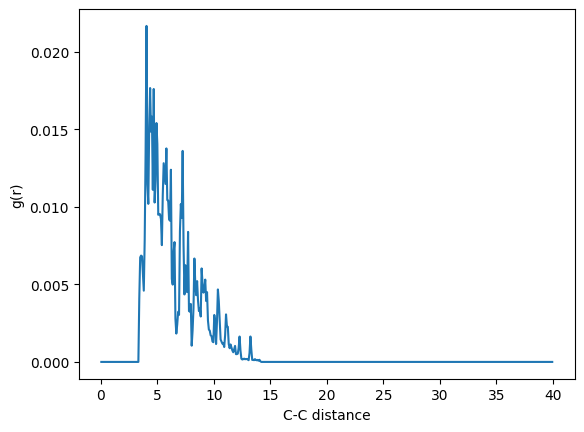

In [138]:
import numpy as np
import matplotlib.pyplot as plt


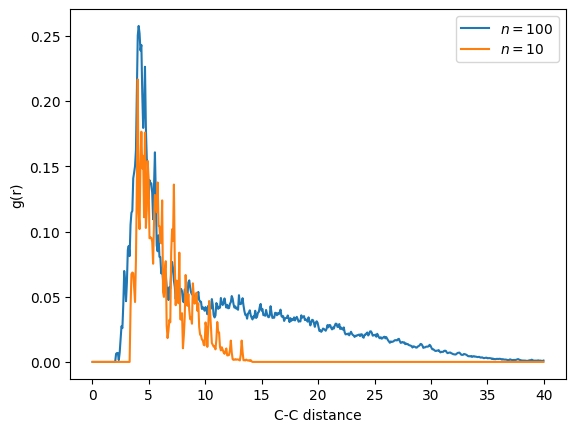

In [145]:
import numpy as np
import matplotlib.pyplot as plt
n_ref=100
counts, bin_edges = np.histogram(dists, bins=500, range=(0, 40), density=False)

r_inner = bin_edges[:-1]
r_outer = bin_edges[1:]
r = 0.5 * (r_inner + r_outer)

shell_volumes = (4.0 / 3.0) * np.pi * (r_outer**3 - r_inner**3)

rho_c = 15 

ideal_counts = n_frames * n_ref * rho_c * shell_volumes

g_r = counts / ideal_counts

plt.plot(r, g_r, label="$n=$100")
plt.xlabel("C-C distance")
plt.ylabel("g(r)")



n_ref=10
counts, bin_edges = np.histogram(dists2, bins=500, range=(0, 40), density=False)

r_inner = bin_edges[:-1]
r_outer = bin_edges[1:]
r = 0.5 * (r_inner + r_outer)

shell_volumes = (4.0 / 3.0) * np.pi * (r_outer**3 - r_inner**3)

rho_c = 15 

ideal_counts = n_frames * n_ref * rho_c * shell_volumes

g_r = counts / ideal_counts

plt.plot(r, g_r, label="$n=$10")
plt.xlabel("C-C distance")
plt.ylabel("g(r)")
plt.legend()
plt.show()

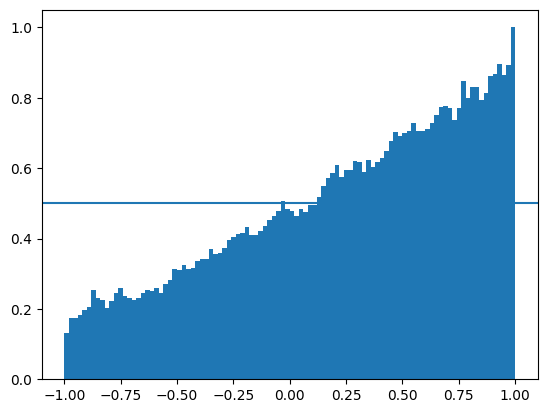

In [157]:
plt.hist(np.cos(np.deg2rad((np.array(360 - np.array(angles))))), bins=100, density=True);
plt.axhline(0.5)

Text(0, 0.5, 'PDE')

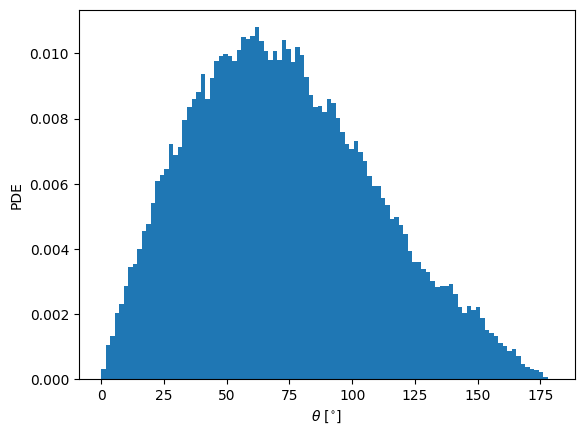

In [161]:
plt.hist(abs(-np.array(angles)), bins=100, density=True);
ax = plt.gca()
ax.set_xlabel("$\\theta$ [$^{\\circ}$]")
ax.set_ylabel("PDE")

In [164]:
dist_angle = np.stack([dists, abs(-np.array(angles))])

In [174]:
plt.hist2d?

Signature:
plt.hist2d(
    x: 'ArrayLike',
    y: 'ArrayLike',
    bins: 'None | int | tuple[int, int] | ArrayLike | tuple[ArrayLike, ArrayLike]' = 10,
    *,
    range: 'ArrayLike | None' = None,
    density: 'bool' = False,
    weights: 'ArrayLike | None' = None,
    cmin: 'float | None' = None,
    cmax: 'float | None' = None,
    data=None,
    **kwargs,
) -> 'tuple[np.ndarray, np.ndarray, np.ndarray, QuadMesh]'
Docstring:
Make a 2D histogram plot.

Parameters
----------
x, y : array-like, shape (n, )
    Input values

bins : None or int or [int, int] or array-like or [array, array]

    The bin specification:

    - If int, the number of bins for the two dimensions
      (``nx = ny = bins``).
    - If ``[int, int]``, the number of bins in each dimension
      (``nx, ny = bins``).
    - If array-like, the bin edges for the two dimensions
      (``x_edges = y_edges = bins``).
    - If ``[array, array]``, the bin edges in each dimension
      (``x_edges, y_edges = bins``).

    The d

In [179]:
shell_volumes

array([2.14466058e-03, 1.50126241e-02, 4.07485511e-02, 7.93524416e-02,
       1.30824296e-01, 1.95164113e-01, 2.72371894e-01, 3.62447639e-01,
       4.65391347e-01, 5.81203018e-01, 7.09882654e-01, 8.51430252e-01,
       1.00584581e+00, 1.17312934e+00, 1.35328083e+00, 1.54630028e+00,
       1.75218770e+00, 1.97094308e+00, 2.20256642e+00, 2.44705773e+00,
       2.70441700e+00, 2.97464423e+00, 3.25773943e+00, 3.55370259e+00,
       3.86253371e+00, 4.18423280e+00, 4.51879985e+00, 4.86623487e+00,
       5.22653785e+00, 5.59970879e+00, 5.98574769e+00, 6.38465456e+00,
       6.79642939e+00, 7.22107219e+00, 7.65858295e+00, 8.10896167e+00,
       8.57220836e+00, 9.04832301e+00, 9.53730562e+00, 1.00391562e+01,
       1.05538747e+01, 1.10814612e+01, 1.16219157e+01, 1.21752381e+01,
       1.27414285e+01, 1.33204869e+01, 1.39124132e+01, 1.45172075e+01,
       1.51348697e+01, 1.57654000e+01, 1.64087981e+01, 1.70650643e+01,
       1.77341984e+01, 1.84162004e+01, 1.91110705e+01, 1.98188085e+01,
      

In [192]:
weights = np.repeat(np.array([1, (4.0 / 3.0) * np.pi ]).T, len(angles), axis=0)
weights.shape, np.array(dists).shape
weights = weights.reshape(4950000, 2)

ValueError: object too deep for desired array

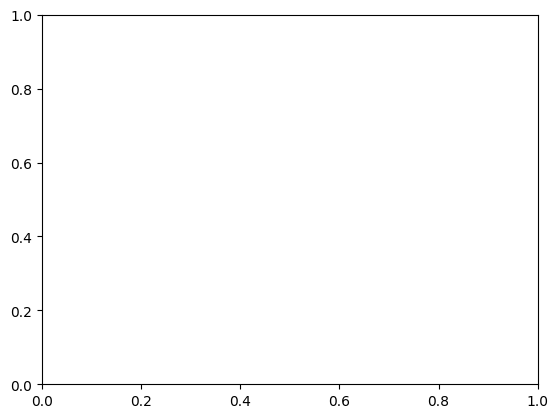

In [193]:
plt.hist2d(dists, abs(-np.array(angles)), bins=70, weights=weights)
# ax = plt.gca()
# ax.set_xlabel("$\\theta$ [$^{\\circ}$]")
# ax.set_ylabel("PDE")

In [63]:
np.cos?

Call signature:  np.cos(*args, **kwargs)
Type:            ufunc
String form:     <ufunc 'cos'>
File:            ~/.local/lib/python3.12/site-packages/numpy/__init__.py
Docstring:      
cos(x, /, out=None, *, where=True, casting='same_kind', order='K', dtype=None, subok=True[, signature])

Cosine element-wise.

Parameters
----------
x : array_like
    Input array in radians.
out : ndarray, None, or tuple of ndarray and None, optional
    A location into which the result is stored. If provided, it must have
    a shape that the inputs broadcast to. If not provided or None,
    a freshly-allocated array is returned. A tuple (possible only as a
    keyword argument) must have length equal to the number of outputs.
where : array_like, optional
    This condition is broadcast over the input. At locations where the
    condition is True, the `out` array will be set to the ufunc result.
    Elsewhere, the `out` array will retain its original value.
    Note that if an uninitialized `out` array